In [1]:
from scipy import stats
from scipy.stats import pearsonr, kendalltau

srcc = stats.spearmanr( [0.6480761, 0.62233955, 0.6661059, 0.631339, 0.6192408, 0.641552, 0.6423639, 0.7225227, 0.65772206, 0.63077545, 0.54655486  , 0.6763791, 0.62823856, 0.63159883, 0.62590545, 0.65006614, 0.6068853, 0.63621056, 0.5723472, 0.6442189, 0.62065214, 0.67560524, 0.6549503, 0.61165047], [0.062, 0.032, 0.029, 0.028, 0.027, 0.104, 0.028, 0.006, 0.033, 0.088, 0.052, 0.014, 0.029, 0.032, 0.022, 0.0, 0.012, 0.04, 0.051, 0.003, 0.032, 0.031, 0.019, 0.042])
srcc0 = pearsonr( [0.6480761, 0.62233955, 0.6661059, 0.631339, 0.6192408, 0.641552, 0.6423639, 0.7225227, 0.65772206, 0.63077545, 0.54655486  , 0.6763791, 0.62823856, 0.63159883, 0.62590545, 0.65006614, 0.6068853, 0.63621056, 0.5723472, 0.6442189, 0.62065214, 0.67560524, 0.6549503, 0.61165047], [0.062, 0.032, 0.029, 0.028, 0.027, 0.104, 0.028, 0.006, 0.033, 0.088, 0.052, 0.014, 0.029, 0.032, 0.022, 0.0, 0.012, 0.04, 0.051, 0.003, 0.032, 0.031, 0.019, 0.042])
srcc1 = kendalltau( [0.6480761, 0.62233955, 0.6661059, 0.631339, 0.6192408, 0.641552, 0.6423639, 0.7225227, 0.65772206, 0.63077545, 0.54655486  , 0.6763791, 0.62823856, 0.63159883, 0.62590545, 0.65006614, 0.6068853, 0.63621056, 0.5723472, 0.6442189, 0.62065214, 0.67560524, 0.6549503, 0.61165047], [0.062, 0.032, 0.029, 0.028, 0.027, 0.104, 0.028, 0.006, 0.033, 0.088, 0.052, 0.014, 0.029, 0.032, 0.022, 0.0, 0.012, 0.04, 0.051, 0.003, 0.032, 0.031, 0.019, 0.042])

srcc[0],srcc0[0],srcc1[0]

(-0.3369615411989142, -0.31079259594045033, -0.23766989273624328)

In [2]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())


NVIDIA GeForce GTX 1050
True


In [3]:
%cd ..


d:\quality_assessment\knowledge_distillation\cvr-iqa\CVRKD-IQA


In [7]:
%pwd

'd:\\quality_assessment\\knowledge_distillation\\cvr-iqa\\CVRKD-IQA'

In [12]:
import glob
import os


# Use glob to find all image files that don't start with a dot
image_files = glob.glob("dataset/kadid10k/images/[!.]*")

# Print the number of image files found
print(f"Number of image files found: {len(image_files)}")




Number of image files found: 10206


(224, 224, 3)

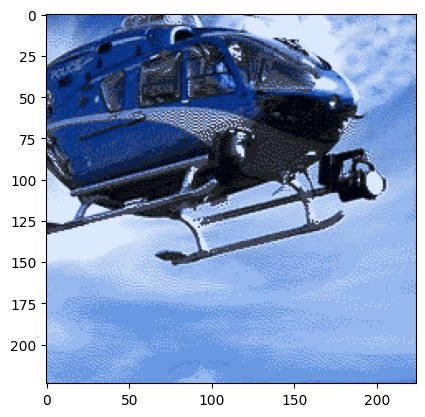

In [20]:
import numpy as np
from PIL import Image
import random

def get_random_patch(image_path, patch_size = 224):
    # Open the image
    img = Image.open(image_path)
    
    # Convert to numpy array
    img_array = np.array(img)
    
    # Get image dimensions
    height, width = img_array.shape[:2]
    
    # Ensure patch size is not larger than image dimensions
    patch_size = min(patch_size, height, width)
    
    # Calculate valid range for top-left corner of patch
    max_x = width - patch_size
    max_y = height - patch_size
    
    # Generate random top-left corner coordinates
    x = random.randint(0, max_x)
    y = random.randint(0, max_y)
    
    # Extract the patch
    patch = img_array[y:y+patch_size, x:x+patch_size]
    
    return patch

# Example usage:
# patch = get_random_patch('path/to/your/image.jpg', 224)
# You can then use this patch for further processing or display


import matplotlib.pyplot as plt

# Example image path - replace with your actual image path
image_path = 'dataset/kadid10k/images/I01_06_04.png'

# Get a random patch
patch = get_random_patch(image_path, patch_size=224)

# Display the patch
plt.imshow(patch)

patch.shape


In [49]:
def get_gray_image_variance(img):
   
    img = Image.fromarray(img.astype('uint8'), 'RGB')
    
  

    gray_img = img.convert('L')
    
    # Convert to numpy array
    gray_array = np.array(gray_img) / 255.0
    
    # Calculate variance of pixel values
    variance = np.var(gray_array)
    
    return variance





In [60]:
patch = get_random_patch(image_path, patch_size=224)

variance = get_gray_image_variance(patch)
print(f"Variance of grayscale image: {variance}")

Variance of grayscale image: 0.05942856439331055


In [ ]:
import os
import random

vars = []

for i in range(3000):
    if i % 500 == 0 :
        print(i)
    random_image = random.choice(image_files)

    # Get a random patch from the selected image
    random_patch = get_random_patch(random_image, patch_size=224)

    # Calculate variance of the grayscale patch
    patch_variance = get_gray_image_variance(random_patch)
    vars.append(patch_variance)
    

In [109]:
import os
import random


random_image = random.choice(image_files)

# Get a random patch from the selected image
random_patch = get_random_patch(random_image, patch_size=224)

# Calculate variance of the grayscale patch
patch_variance = get_gray_image_variance(random_patch)

print(f"Selected image: {random_image}")
print(f"Variance of grayscale patch: {patch_variance}")

# Display the patch
plt.imshow(random_patch)
plt.title(f"Random patch from {random_image}")
plt.show()

0
500
1000
1500
2000
2500


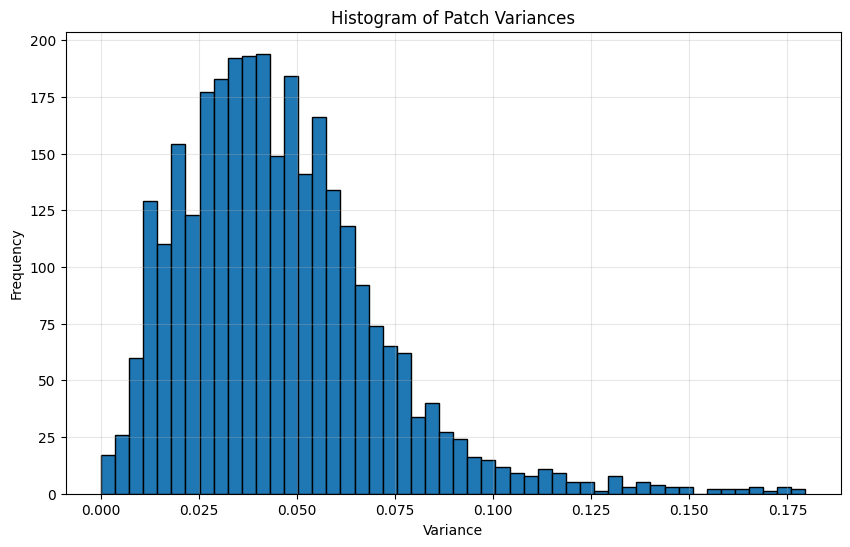

Minimum variance: 0.0
Maximum variance: 0.1795803424770643
Mean variance: 0.045703727660293965


In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(vars, bins=50, edgecolor='black')
plt.title('Histogram of Patch Variances')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and print some statistics
print(f"Minimum variance: {min(vars)}")
print(f"Maximum variance: {max(vars)}")
print(f"Mean variance: {sum(vars) / len(vars)}")


In [125]:
# Count the number of patches with variance greater than 0.05
count_high_variance = sum(1 for var in vars if var > 0.06)


count_high_variance / len(vars)

0.23566666666666666

In [178]:
import numpy as np
import cv2
from scipy.fftpack import dct, idct

def dct_compress_reconstruct(image, n_coeffs=256):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    # Apply 2D DCT
    dct_coeffs = dct(dct(gray.T, norm='ortho').T, norm='ortho')
    
    # Keep only the n_coeffs most significant coefficients
    dct_coeffs_top = np.zeros_like(dct_coeffs)
    r, c = dct_coeffs.shape
    dct_coeffs_top[:int(np.sqrt(2 * n_coeffs)), :int(np.sqrt(2 * n_coeffs))] = dct_coeffs[:int(np.sqrt(2 * n_coeffs)), :int(np.sqrt(2 * n_coeffs))]
    



    matrix = np.zeros_like(dct_coeffs)

    # Create a triangle in the upper left corner
    for i in range(int(np.sqrt(2 * n_coeffs))):
        for j in range(int(np.sqrt(2 * n_coeffs) - i)):
            matrix[i, j] = 1

    # Create a boolean mask from the matrix
    bool_mask = matrix.astype(bool)

    # Perform boolean matrix multiplication
    dct_coeffs_top[~bool_mask] = 0

    # Serialize the DCT coefficients based on the boolean mask
    serialized_coeffs = dct_coeffs[bool_mask]
    

    
    return serialized_coeffs

# Example usage:
# Assuming 'random_patch' is your input image
for i in range(4):
    serialized_coeffs = dct_compress_reconstruct(random_patch ,100 )
    print(len(serialized_coeffs))




105
105
105
105


In [184]:
((4/5) ** 5  ) * 0.06

0.019660800000000003